In [62]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')

from lambda_cox import LambdaSA
from utils import concordance_index, unroll
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
config_path = '../config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [38]:
agent = LambdaSA(config, 42)

In [4]:
xs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = xs.shape
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [5]:
xs.shape

(467, 5, 10)

In [33]:
num_exps = 5
briers = []
concs = []

for i in range(num_exps):
    X_train, X_test, ts_train, ts_test, cs_train, cs_test = agent._get_train_test()
    _ = agent.train(X_train, ts_train, cs_train)
    
    

In [77]:
#Train
losses = agent.train(X_train, ts_train, cs_train)

In [27]:
losses = np.array(losses)

In [35]:
agent.integrated_brier_score(X_train, ts_train, cs_train)

Array(0.2552234, dtype=float32)

In [46]:
agent.integrated_brier_score(X_test, ts_test, cs_test)

Array(0.20428069, dtype=float32)

In [44]:
beta = agent.state.params['cox_linear_model']['beta']

In [31]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [45]:
scores = score(beta, X_train[:,0])

concordance_index(scores, ts_train, cs_train)

0.6573645290338223

In [78]:
agent.state.params

{'cox_linear_model': {'alpha': Array([-0.27259287, -0.08340714,  0.09808528,  0.17341521,  0.3611179 ],      dtype=float32),
  'beta': Array([-0.20342898,  0.21092841,  0.07669841, -0.36684227, -0.29806918,
         -2.1064842 , -1.545205  , -1.0494    , -0.60995954,  0.        ],      dtype=float32)}}

In [51]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
    )

In [54]:
model = LambdaSA(config, 42)

In [56]:
seqs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']

In [82]:
%%time

sizes = 20 * jnp.arange(1, 11)

res2_is = np.zeros((n_folds, len(sizes)))
res2_lm = np.zeros((n_folds, len(sizes)))
res2_td = np.zeros((n_folds, len(sizes)))

res3_is = np.zeros((n_folds, len(sizes)))
res3_lm = np.zeros((n_folds, len(sizes)))
res3_td = np.zeros((n_folds, len(sizes)))

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])
        
        # Initial state.
        model = LambdaSA(config, 42)
        model.train(seqs_t[:size], ts_t[:size], cs_t[:size])
        res2_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Landmarking.
        model = LambdaSA(config, 42)
        model.lambda_ = 1.0
        model.train(seqs_, ts_, cs_)
        res2_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts_v, cs_v)
        
        # Temporal difference.
        model = LambdaSA(config, 42)
        model.lambda_ = 0.0
        model.train(seqs_, ts_, cs_)
        res2_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs_v[:, 0])
        res3_td[fold, i] = concordance_index(scores, ts_v, cs_v)
        
    print()

..........
..........
..........
..........
..........
CPU times: user 1min 10s, sys: 2.03 s, total: 1min 12s
Wall time: 1min 10s


Text(0.5, 0, 'Number of patients')

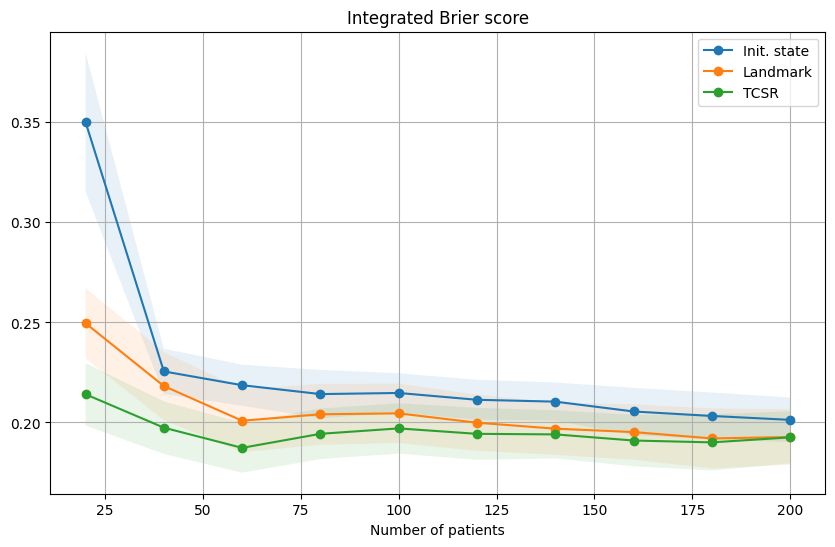

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark"), (res2_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Number of patients")

Text(0.5, 0, 'Number of patients')

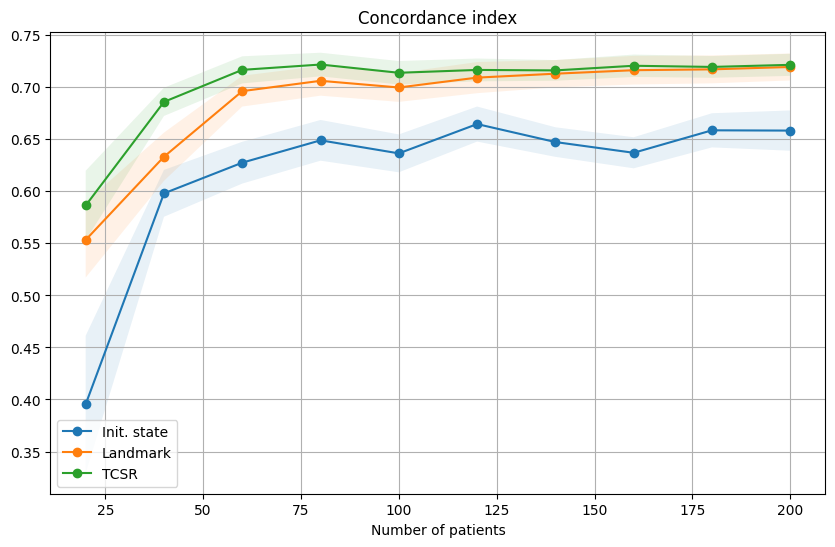

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark"), (res3_td, "TCSR")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(n_folds)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")

In [85]:
beta

Array([-0.32855573,  0.41633797,  0.30488542, -0.47706458, -0.45256257,
       -1.6174251 , -1.228589  , -0.88426363, -0.53857446,  0.        ],      dtype=float32)

In [111]:
ys, ws = model._targets(5, seqs_v, ts_v, cs_v)

In [112]:
ys[4]

Array([1., 0., 0., 0., 0.], dtype=float32)

In [107]:
ts_v[4]

Array(1, dtype=int32)

In [106]:
cs_v[4]

Array(False, dtype=bool)

In [113]:
ws[4]

Array([1., 0., 0., 0., 0.], dtype=float32)

In [119]:
multipliers = 0.1 ** jnp.arange(model.config.horizon)

In [120]:
multipliers

Array([1.00000000e+00, 1.00000001e-01, 1.00000007e-02, 1.00000005e-03,
       1.00000005e-04], dtype=float32, weak_type=True)

In [121]:
losses = model.train(seqs_t[:size], ts_t[:size], cs_t[:size])

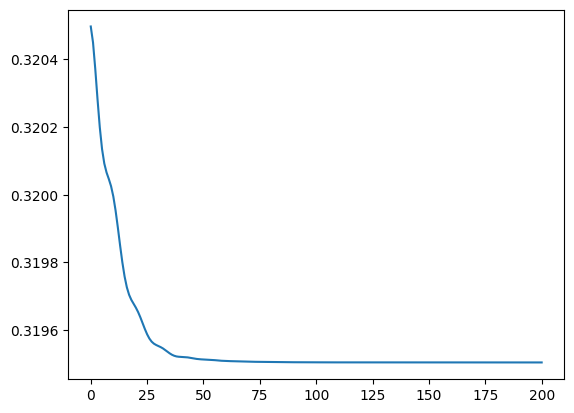

In [126]:
plt.plot(losses[0])

Array([ 20,  40,  60,  80, 100, 120, 140, 160, 180, 200], dtype=int32)